In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from mpl_toolkits.mplot3d import Axes3D
from WelfareMeasures import *
from functions_njit import tax_rate_fct
from bernoulli_distribution import Bernoulli
from help_functions_non_njit import *
from graph_format import *
# load local model file and initialize model class
from model import ModelClass
from scipy.optimize import minimize

# Load original model

In [2]:
model = ModelClass() # set a few number of periods.

par = model.par
sol = model.sol
sim = model.sim
par.opt_tol = 1e-6
par.opt_maxiter = 1000

%time model.solve(do_print=False)
%time model.simulate()

CPU times: total: 28min 13s
Wall time: 4min 13s
CPU times: total: 1min 1s
Wall time: 31.6 s


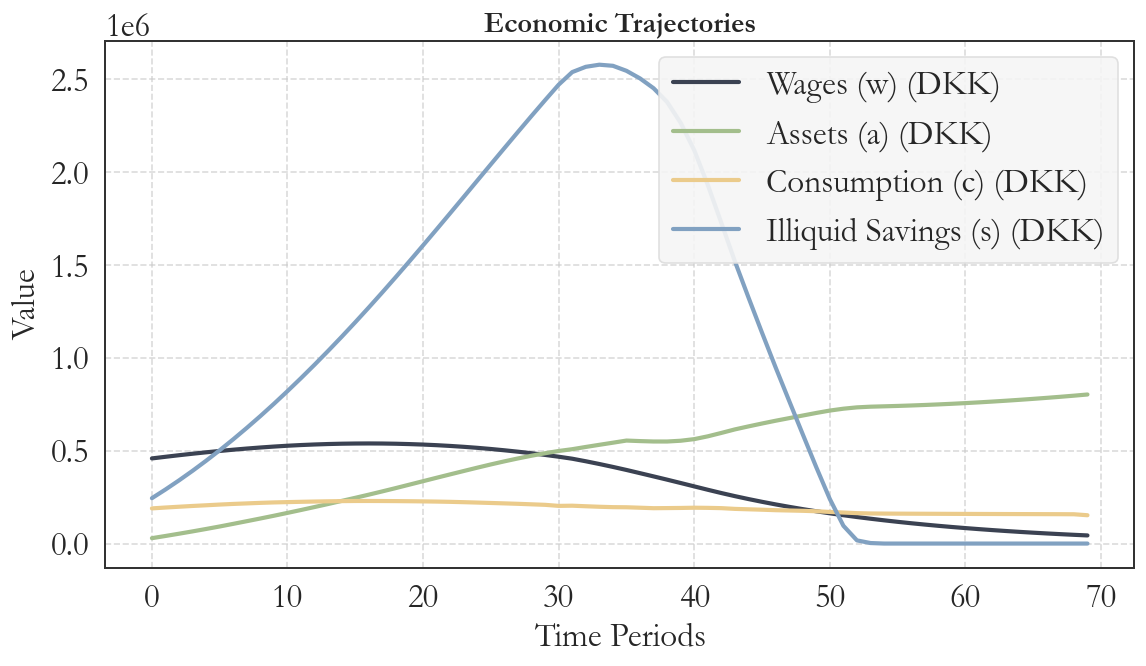

In [3]:
time = np.arange(par.T)
data_dict_basic = {
    "Wages (w)": {"data": np.mean(model.sim.w[:], axis=0), "unit": "DKK"},
    "Assets (a)": {"data": np.mean(model.sim.a[:], axis=0), "unit": "DKK"},
    "Consumption (c)": {"data": np.mean(model.sim.c[:], axis=0), "unit": "DKK"},
    "Illiquid Savings (s)": {"data": np.mean(model.sim.s[:], axis=0), "unit": "DKK"},
}

plot_simulation_one_graph(data_dict_basic, time, title="Economic Trajectories")

# Counter factual

In [4]:
# Change parameters and re-solve
theta = [2]
theta_names = ['early_benefits_lag']

og_model, new_model =  make_new_model(model, theta, theta_names, do_print = False)


# Labor supply

Expected welfare  before parameter changes: -22.12986137377154
Expected welfare after parameter changes: -22.132915097211338
Consumption at every age before the policy change must change with -0.1 pct. to keep the same utility, and analytically: -0.1 pct.


c:\Users\peter\Desktop\Speciale\Design_retirement\WelfareMeasures.py:83: RuntimeWarning: Mean of empty slice
  sim_og_h = np.nanmean(sim_og_h_ex_1, axis=0)# age specific average
c:\Users\peter\Desktop\Speciale\Design_retirement\WelfareMeasures.py:84: RuntimeWarning: Mean of empty slice
  sim_new_h = np.nanmean(sim_new_h_ex_1, axis=0) # age specific average


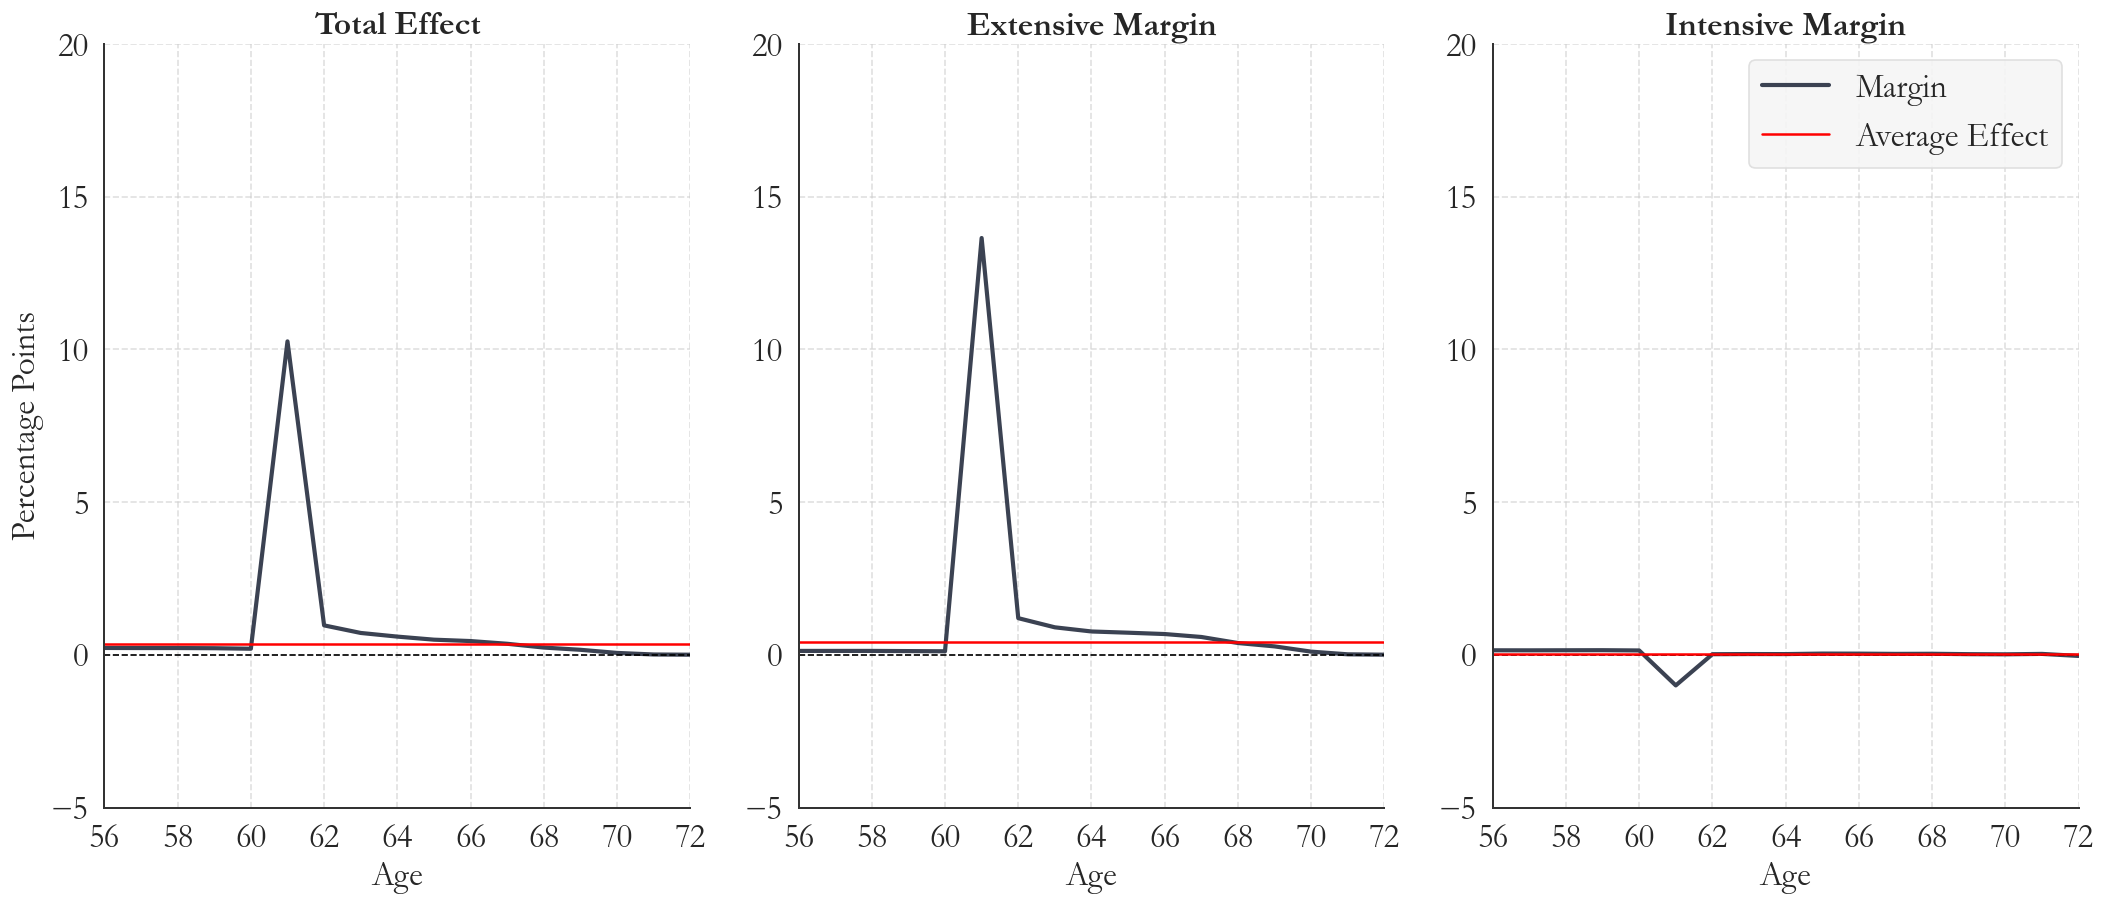

0.003613240035429697

In [5]:
# Compare models 
consumption_eq = find_consumption_equivalence(og_model, new_model, do_print= True, the_method = 'brentq')
intensive_margin, extensive_margin, total_margin, total_per_person, intensive_margin_age, extensive_margin_age, total_margin_age  = labor_elasticity(og_model, new_model)


plot_labor_margins_by_age(
    intensive_age=intensive_margin_age,
    extensive_age=extensive_margin_age,
    total_age=total_margin_age,
    avg_intensive=intensive_margin,
    avg_extensive=extensive_margin,
    avg_total=total_margin,
    age_start=par.start_age,
    # title_prefix="Labor Supply — ",
    save_title="CF_ef_age_2_labor.png",
    ylim_total=(-5, 20),
    ylim_extensive=(-5, 20),
    ylim_intensive=(-5, 20)
)

total_margin

## Unanticipated shock

In [6]:
unanticipated_model = new_model.copy()

unanticipated_model.simulate_unanticipated(og_model)

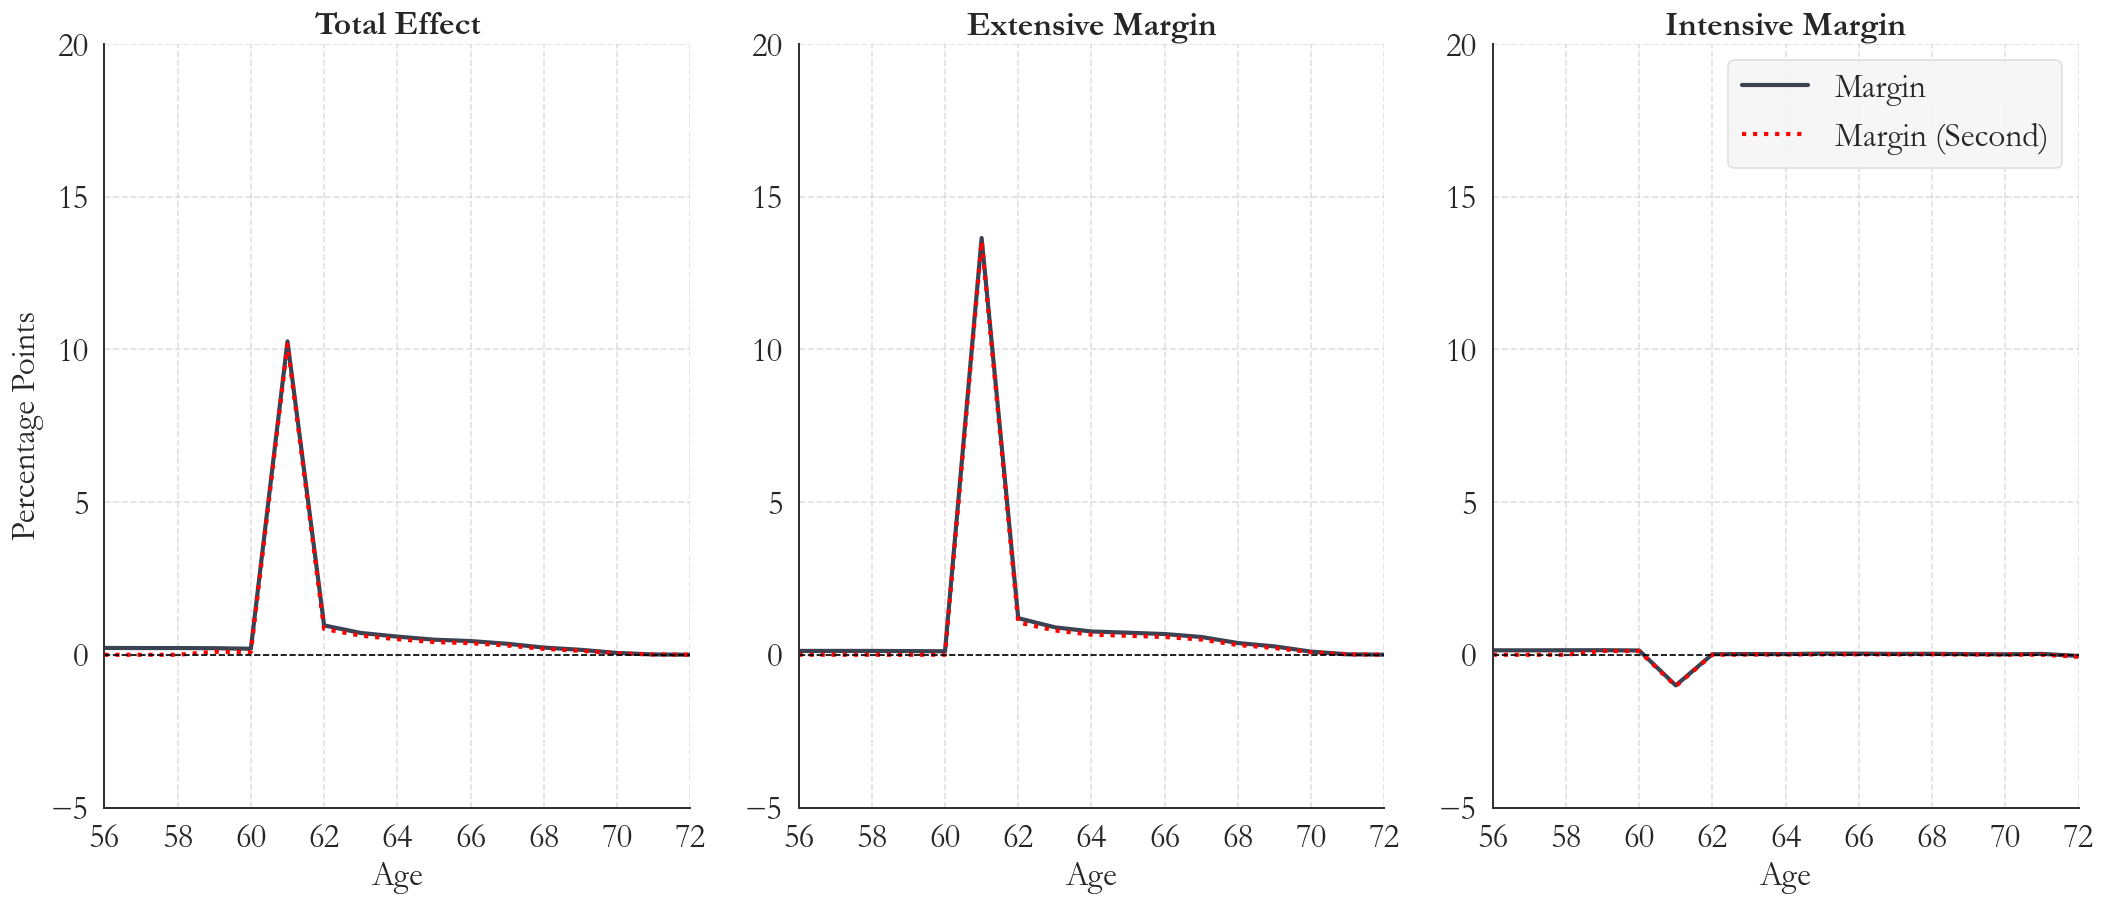

(0.003613240035429697, 0.0025067033969235148)

In [12]:
# Compare models 
# consumption_eq = find_consumption_equivalence(og_model, unanticipated_model, do_print=True, the_method='brentq')

intensive_margin_first, extensive_margin_first, total_margin_first, total_per_person_first, \
    intensive_margin_age_first, extensive_margin_age_first, total_margin_age_first = labor_elasticity(og_model, new_model)

intensive_margin_second, extensive_margin_second, total_margin_second, total_per_person_second, \
    intensive_margin_age_second, extensive_margin_age_second, total_margin_age_second = labor_elasticity(og_model, unanticipated_model)


plot_labor_margins_by_age_multiple(
    # first set
    intensive_age=intensive_margin_age_first,
    extensive_age=extensive_margin_age_first,
    total_age=total_margin_age_first,
    avg_intensive=intensive_margin_first,
    avg_extensive=extensive_margin_first,
    avg_total=total_margin_first,
    # second set (dotted)
    intensive_age_second=intensive_margin_age_second,
    extensive_age_second=extensive_margin_age_second,
    total_age_second=total_margin_age_second,
    avg_intensive_second=intensive_margin_second,
    avg_extensive_second=extensive_margin_second,
    avg_total_second=total_margin_second,
    age_start=par.start_age,
    save_title="CF_ef_age_2_labor.png",
    ylim_total=(-5, 20),
    ylim_extensive=(-5, 20),
    ylim_intensive=(-5, 20)
)

# inspect overall total margin if desired
total_margin_first, total_margin_second
